# COMPARISON — GEGRU cross-dataset generalization audit (DELCODE / ADNI / OASIS3)

Real DELCODE test-set evaluation of the trained GEGRU model
(`gegru-trajectory-whole-brain`) + a quantitative scanner/site-heterogeneity
characterization of DELCODE, ADNI, and OASIS3 from existing metadata, with
**pre-registered evaluation stubs** for ADNI and OASIS3 that activate automatically
once those cohorts' Schaefer-200 FC matrices exist
(`DATA/<cohort>/__fc_wholebrain_sch200_flat__/matrices/` or
`__fmri_wholebrain_sch200_flat__/` for ADNI).

This notebook does **not** claim the model has been validated on ADNI or OASIS3 —
those cohorts have no preprocessed connectivity data yet (raw DICOM/NIfTI only; see
`DATA/src/processing/`). What it does provide: a real DELCODE number, an honest
inventory of how different the other two cohorts' scanners are, and a
`site_heterogeneity_stats.json` calibration anchor consumed by
`SANITY_GEGRU_SYNTHETIC_SCANNER_DRIFT.ipynb` to simulate that heterogeneity.


In [1]:
# === Papermill parameters ===
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                 # adapter registry key; None -> 'gelstm' (GEGRU is rnn_type=gru)
SOURCE_EXPERIMENT = None       # trained run to reload; None -> 'gegru-trajectory-whole-brain'
SEED = 42
WANDB_ENABLED = False
OUTPUT_DIR = None
RUN_DIR = None
RUN_NAME = None


## Pipeline overview

Reload the saved `gegru-trajectory-whole-brain` run (`adapter.load_state` +
`read_run_threshold` — no training) -> score the real DELCODE test split ->
characterize ADNI/OASIS3 scanner metadata -> compute and persist the drift
calibration anchor -> guarded ADNI/OASIS3 model-scoring stubs.


In [2]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))


In [3]:
# reproducibility seeding — must run before datasets / models.
from SHARED.seeding import set_seed, make_rng, make_torch_generator
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)


In [4]:
import json, os, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sk_auc, classification_report

from SHARED.sanity import run_full_audit
from common.crossval import Bundle
from adapters import get_adapter, read_run_threshold
from adapters.explain import resolve_source_run

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Imports OK  |  device:', device)


/tmp/ipykernel_1942876/2110841871.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Imports OK  |  device: cuda


## Configuration

In [5]:
from DATA.DELCODE.src.splitting.load_splits import splits_dir, split_csv_paths

# DELCODE -- preprocessed, used for the real evaluation arm.
DELCODE_DATA_ROOT = str(repo_root / 'DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices')
DELCODE_METADATA_DIR = str(repo_root / 'DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata')
DELCODE_COHORTS_CSV = os.path.join(DELCODE_METADATA_DIR, 'cohorts_with_scans_on_disk.csv')
SPLITS_DIR = str(splits_dir('downstream'))
TEST_CSV = os.path.join(SPLITS_DIR, 'test.csv')

# ADNI / OASIS3 -- same directory convention as DELCODE; consumed by the guarded
# loader below once DATA/DELCODE/src/processing has produced their matrices + a
# DELCODE-shaped cohorts.csv.
ADNI_DATA_ROOT = str(repo_root / 'DATA/ADNI/__fmri_wholebrain_sch200_flat__/matrices')
ADNI_COHORTS_CSV = str(repo_root / 'DATA/ADNI/__fmri_wholebrain_sch200_flat__/metadata/cohorts.csv')
ADNI_SCANNER_CSV = str(repo_root / 'DATA/ADNI/__metadata__/All_Subjects_Functional_MRI_Images_12May2026.csv')

OASIS3_DATA_ROOT = str(repo_root / 'DATA/OASIS3/__fc_wholebrain_sch200_flat__/matrices')
OASIS3_COHORTS_CSV = str(repo_root / 'DATA/OASIS3/__fc_wholebrain_sch200_flat__/metadata/cohorts.csv')
OASIS3_SCANNER_CSV = str(repo_root / 'DATA/OASIS3/__metadata__/OASIS3_MR_json.csv')

EXPERIMENT_ID = EXPERIMENT_ID or 'comparison-gegru-cross-dataset'
OUTPUT_DIR = Path(OUTPUT_DIR) if OUTPUT_DIR else (model_root / 'outputs' / EXPERIMENT_ID / 'standalone')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTPUT_DIR)


Output dir: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/comparison-gegru-cross-dataset/standalone


In [6]:
# split-hygiene audit -- hard-fails if any subject crosses splits.
_ = run_full_audit(split_csv_paths('downstream'))


[SANITY] Split sizes: {'train': 99, 'val': 34, 'test': 34}
[SANITY] Pairwise-disjoint: OK


## Reload the trained GEGRU run

No training here -- `adapter.load_state(run_dir)` rebuilds the composite eval
state from the saved checkpoint, and `read_run_threshold` reads the
validation-derived threshold (Best-F1, for this run). Same reload pattern as
`EXPLAIN_COMMON_DELCODE.ipynb`'s classifier path.


In [7]:
SOURCE_EXPERIMENT = SOURCE_EXPERIMENT or 'gegru-trajectory-whole-brain'
RUN_DIR = resolve_source_run(SOURCE_EXPERIMENT, classifier_root=model_root)
SUMMARY = json.loads((RUN_DIR / 'run_summary.json').read_text())

# GAAE architecture + graph-construction hyperparameters (incl. adjacency_k,
# file_variant) must match what the run was trained with -- these live in the
# GAAE config, not run_summary.json's model_config (which only records the
# encoder's output shape, not how the kNN graph was built).
GAAE_CONFIG_PATH = model_root / 'configs' / 'gaae_delcode_whole_brain.json'
GAAE_HP = json.loads(GAAE_CONFIG_PATH.read_text())
GAAE_CKPT_PATH = SUMMARY['gaae_checkpoint']

adapter = get_adapter(ADAPTER or 'gelstm')(
    gaae_ckpt_path=GAAE_CKPT_PATH, gaae_hp=GAAE_HP, train_config=SUMMARY['training_config'],
    data_root=DELCODE_DATA_ROOT, cohorts_csv=DELCODE_COHORTS_CSV, device=device, rng=rng,
)
STATE = adapter.load_state(RUN_DIR)
THRESHOLD = read_run_threshold(RUN_DIR)

print(f'Reloaded {SOURCE_EXPERIMENT!r} from {RUN_DIR.name}')
print(f"Saved test AUC: {SUMMARY['metrics']['test_auc']:.4f}   "
      f"Threshold: {THRESHOLD:.4f} ({SUMMARY['threshold_method']})")


Reloaded 'gegru-trajectory-whole-brain' from lucky-harbor-3-d9655b0db-2026-06-21_13-50-00
Saved test AUC: 0.8321   Threshold: 0.6594 (oof_f1)


In [ ]:
import sys as _sys
if '/mnt/e/fyassine/ad-early-detection' not in _sys.path:
    _sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection')
from SHARED.plotting import add_note, format_model_runs_note, run_name_from_checkpoint_path

MODEL_RUNS = {
    "GAAE": run_name_from_checkpoint_path(SUMMARY['gaae_checkpoint']),
    "GEGRU": RUN_DIR.name,
}


## DELCODE arm — real evaluation

In [8]:
test_df = pd.read_csv(TEST_CSV)
DELCODE_BUNDLE = adapter.prepare_data(test_df)
DELCODE_METRICS = adapter.eval_split(STATE, DELCODE_BUNDLE, THRESHOLD, device=device)

print('DELCODE test-set results (real)')
print('=' * 40)
print(f"AUC:         {DELCODE_METRICS['auc']:.4f}")
print(f"Sensitivity: {DELCODE_METRICS['sensitivity']:.4f}")
print(f"Specificity: {DELCODE_METRICS['specificity']:.4f}")
print(f"F1:          {DELCODE_METRICS['f1']:.4f}")
print()
print(classification_report(
    DELCODE_METRICS['targets'],
    (np.asarray(DELCODE_METRICS['probs']) >= THRESHOLD).astype(int),
    target_names=['stable_mci', 'converter'],
))


LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=6  mean=2.9


[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth


DELCODE test-set results (real)
AUC:         0.8321
Sensitivity: 0.6429
Specificity: 0.7500
F1:          0.6429

              precision    recall  f1-score   support

  stable_mci       0.75      0.75      0.75        20
   converter       0.64      0.64      0.64        14

    accuracy                           0.71        34
   macro avg       0.70      0.70      0.70        34
weighted avg       0.71      0.71      0.71        34



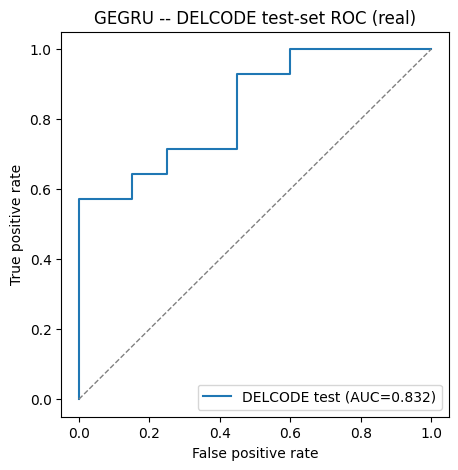

In [9]:
fpr, tpr, _ = roc_curve(DELCODE_METRICS['targets'], DELCODE_METRICS['probs'])
roc_auc = sk_auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f'DELCODE test (AUC={roc_auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('GEGRU -- DELCODE test-set ROC (real)')
ax.legend()
fig.savefig(FIGURES_DIR / 'delcode_test_roc.png', dpi=150, bbox_inches='tight')
add_note(fig, list(fig.axes), format_model_runs_note(MODEL_RUNS))
plt.show()


## Scanner / site heterogeneity — ADNI and OASIS3 metadata

DELCODE's `cohorts.csv` has no scanner/site columns (single-protocol cohort, not
tracked). ADNI and OASIS3 do -- this section quantifies how different their
acquisition protocols are, which is the real-world driver of the AUC drop the
cover-letter draft describes for DELCODE-to-ADNI generalization. These numbers
(not vendor counts alone) calibrate the drift simulation in
`SANITY_GEGRU_SYNTHETIC_SCANNER_DRIFT.ipynb`.


In [10]:
adni_scan = pd.read_csv(ADNI_SCANNER_CSV)
print('ADNI fMRI scanner records:', len(adni_scan))
print(adni_scan['fmri_mfr'].value_counts())
print()
print(adni_scan['fmri_mfr_model'].value_counts().head(10))
print()
print(adni_scan['fmri_field_str'].value_counts())


ADNI fMRI scanner records: 18616
fmri_mfr
SIEMENS               14056
Philips                2416
GE MEDICAL SYSTEMS     2144
Name: count, dtype: int64

fmri_mfr_model
TrioTim                4616
Prisma_fit             2950
Skyra                  1897
Verio                  1734
Prisma                 1472
DISCOVERY MR750        1146
Achieva                 697
Ingenia                 671
MAGNETOM Prisma Fit     566
Achieva dStream         561
Name: count, dtype: int64

fmri_field_str
3.0    18614
1.5        2
Name: count, dtype: int64


In [11]:
oasis_scan = pd.read_csv(OASIS3_SCANNER_CSV)
print('OASIS3 MR scanner records:', len(oasis_scan))
print(oasis_scan['Manufacturer'].value_counts())
print()
print(oasis_scan['ManufacturersModelName'].value_counts())
print()
print(oasis_scan['MagneticFieldStrength'].value_counts())


OASIS3 MR scanner records: 30339
Manufacturer
Siemens    30339
Name: count, dtype: int64

ManufacturersModelName
TrioTim             17840
Biograph_mMR         7592
MAGNETOM_Vida        3795
Vision                980
Sonata                123
Avanto                  6
Prisma_fit              2
MR_MAGNETOM_Vida        1
Name: count, dtype: int64

MagneticFieldStrength
3.000    29230
1.500     1041
1.494       68
Name: count, dtype: int64


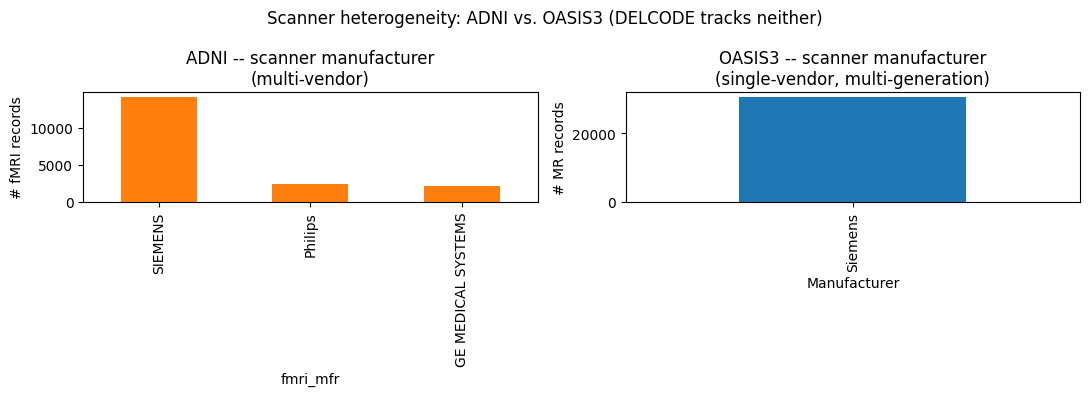

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

adni_scan['fmri_mfr'].value_counts().plot(kind='bar', ax=axes[0], color='tab:orange')
axes[0].set_title('ADNI -- scanner manufacturer\n(multi-vendor)')
axes[0].set_ylabel('# fMRI records')

oasis_scan['Manufacturer'].value_counts().plot(kind='bar', ax=axes[1], color='tab:blue')
axes[1].set_title('OASIS3 -- scanner manufacturer\n(single-vendor, multi-generation)')
axes[1].set_ylabel('# MR records')

fig.suptitle('Scanner heterogeneity: ADNI vs. OASIS3 (DELCODE tracks neither)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'scanner_heterogeneity_comparison.png', dpi=150, bbox_inches='tight')
add_note(fig, list(fig.axes), format_model_runs_note(MODEL_RUNS))
plt.show()


## Calibration anchor for the drift simulation

Two real numbers, persisted to `site_heterogeneity_stats.json`:

* **DELCODE natural floor** — std of edge-wise FC differences between
  consecutive same-subject visits (a test-retest-like proxy already present in
  the matrices), expressed as a fraction of the typical per-graph FC value
  spread. This is in the same units as `perturb_graph`'s `noise_level`
  parameter (it scales injected noise by each graph's own std), so
  `base_noise_level` is literally "one natural-visit-equivalent unit of drift."
* **Relative dispersion multipliers** — coefficient of variation (`std/mean`)
  of acquisition TR across ADNI's and OASIS3's scanner records.

`SANITY_GEGRU_SYNTHETIC_SCANNER_DRIFT.ipynb` sets
`noise_level_<site> = base_noise_level * (1 + CV_<site>)` from this file instead
of hardcoding a noise magnitude.


In [13]:
def _consecutive_visit_fc_delta_std(bundle):
    deltas = []
    for item in bundle.items:
        graphs = item['graphs']
        for i in range(1, len(graphs)):
            deltas.append((graphs[i].x - graphs[i - 1].x).numpy().ravel())
    if not deltas:
        raise ValueError('No subjects with >=2 visits -- cannot compute the DELCODE floor.')
    return float(np.std(np.concatenate(deltas)))

def _typical_fc_std(bundle):
    stds = [g.x.std().item() for item in bundle.items for g in item['graphs']]
    return float(np.mean(stds))

def _cv(series):
    s = pd.to_numeric(series, errors='coerce').dropna()
    return float(s.std() / s.mean()) if len(s) and s.mean() != 0 else float('nan')

DELCODE_FLOOR_STD = _consecutive_visit_fc_delta_std(DELCODE_BUNDLE)
TYPICAL_FC_STD = _typical_fc_std(DELCODE_BUNDLE)
BASE_NOISE_LEVEL = DELCODE_FLOOR_STD / TYPICAL_FC_STD

# ADNI's scanner CSV is already fMRI-only (file name says so). OASIS3's
# OASIS3_MR_json.csv dumps EVERY MR series (T1, DTI, fieldmaps, ASL, ...) for
# every session, not just resting-state BOLD -- computing a TR-CV over all of
# it conflates "TR varies because sequence type varies" with genuine
# scanner/protocol drift within the fMRI series this model actually consumes.
# Restrict to the resting-state BOLD series (the ep2d_bold* / *rsfMRI*
# SeriesDescriptions) before computing the CV.
oasis_bold = oasis_scan[oasis_scan['SeriesDescription'].str.contains(
    'bold|rsfmri', case=False, na=False, regex=True)]
print(f"OASIS3 resting-state BOLD series: {len(oasis_bold)} / {len(oasis_scan)} total MR records")

CV_ADNI = _cv(adni_scan['fmri_tr'])
CV_OASIS3 = _cv(oasis_bold['RepetitionTime'])

SITE_HETEROGENEITY_STATS = {
    'delcode_consecutive_visit_fc_delta_std': DELCODE_FLOOR_STD,
    'typical_fc_std': TYPICAL_FC_STD,
    'base_noise_level': BASE_NOISE_LEVEL,
    'adni_tr_cv': CV_ADNI,
    'oasis3_tr_cv': CV_OASIS3,
    'note': ('base_noise_level = DELCODE natural inter-visit FC-delta std / typical '
             'FC value std (a perturb_graph-noise_level-unit drift floor). '
             'CV = std/mean of acquisition TR across scanner records, restricted to '
             'resting-state BOLD series for OASIS3 (its metadata otherwise mixes in '
             'T1/DTI/fieldmap/ASL TRs from unrelated sequence types). The drift '
             'notebook sets noise_level_<site> = base_noise_level * (1 + CV_<site>).'),
}
with open(OUTPUT_DIR / 'site_heterogeneity_stats.json', 'w') as f:
    json.dump(SITE_HETEROGENEITY_STATS, f, indent=2)
print(json.dumps(SITE_HETEROGENEITY_STATS, indent=2))


OASIS3 resting-state BOLD series: 5124 / 30339 total MR records
{
  "delcode_consecutive_visit_fc_delta_std": 0.2635538876056671,
  "typical_fc_std": 0.26554680713499434,
  "base_noise_level": 0.9924950348647419,
  "adni_tr_cv": 0.38145576325718394,
  "oasis3_tr_cv": 0.35847226323162534,
  "note": "base_noise_level = DELCODE natural inter-visit FC-delta std / typical FC value std (a perturb_graph-noise_level-unit drift floor). CV = std/mean of acquisition TR across scanner records, restricted to resting-state BOLD series for OASIS3 (its metadata otherwise mixes in T1/DTI/fieldmap/ASL TRs from unrelated sequence types). The drift notebook sets noise_level_<site> = base_noise_level * (1 + CV_<site>)."
}


## Why this matters beyond neuroimaging

The same failure mode shows up in digital pathology: a model trained on
whole-slide images from one scanner/stain protocol can look excellent in-house
and degrade sharply on a second site's slides, driven by scanner-vendor color
response, stain-batch variation, and tissue-prep differences -- the
histopathology analogue of the MRI manufacturer/field-strength/TR heterogeneity
quantified above. The methodology is the same either way: stratify performance
by site/scanner, trace failures back to acquisition metadata, and make the
degradation explicit (the calibration anchor + drift sweep in
`SANITY_GEGRU_SYNTHETIC_SCANNER_DRIFT.ipynb`) rather than reporting a single
flattering AUC.


## ADNI / OASIS3 model-scoring stubs (pending preprocessing)

Guarded: each call below checks for `.npz` matrices + a DELCODE-shaped
`cohorts.csv` under the cohort's directory and skips with a message if either is
missing (true today for both ADNI and OASIS3). The moment
`DATA/src/processing` produces them, re-running this cell scores the reloaded
GEGRU model on that cohort with no code changes.


In [14]:
def try_eval_external_cohort(name, data_root, cohorts_csv):
    npz_files = list(Path(data_root).glob('*.npz')) if Path(data_root).is_dir() else []
    if not npz_files or not Path(cohorts_csv).is_file():
        print(f'[{name}] not preprocessed yet -- found {len(npz_files)} matrices, '
              f'cohorts_csv exists={Path(cohorts_csv).is_file()}. Skipping.')
        return None
    subject_df = pd.read_csv(cohorts_csv).drop_duplicates('Pseudonym')
    bundle = adapter.prepare_data(subject_df)
    metrics = adapter.eval_split(STATE, bundle, THRESHOLD, device=device)
    print(f"[{name}] AUC={metrics['auc']:.4f}  n={len(bundle)}")
    return metrics

ADNI_METRICS = try_eval_external_cohort('ADNI', ADNI_DATA_ROOT, ADNI_COHORTS_CSV)
OASIS3_METRICS = try_eval_external_cohort('OASIS3', OASIS3_DATA_ROOT, OASIS3_COHORTS_CSV)


[ADNI] not preprocessed yet -- found 0 matrices, cohorts_csv exists=False. Skipping.
[OASIS3] not preprocessed yet -- found 0 matrices, cohorts_csv exists=False. Skipping.


## Aggregate results

In [15]:
def _metrics_or_empty(m):
    return {k: m[k] for k in ('auc', 'sensitivity', 'specificity', 'f1')} if m else {}

RESULTS = {
    'delcode': {
        'status': 'real', 'n_subjects': len(DELCODE_BUNDLE),
        **_metrics_or_empty(DELCODE_METRICS),
    },
    'adni': {
        'status': 'real' if ADNI_METRICS else 'pending_preprocessing',
        **_metrics_or_empty(ADNI_METRICS),
        'scanner_manufacturers': adni_scan['fmri_mfr'].value_counts().to_dict(),
    },
    'oasis3': {
        'status': 'real' if OASIS3_METRICS else 'pending_preprocessing',
        **_metrics_or_empty(OASIS3_METRICS),
        'scanner_manufacturers': oasis_scan['Manufacturer'].value_counts().to_dict(),
    },
}
with open(OUTPUT_DIR / 'comparison_summary.json', 'w') as f:
    json.dump(RESULTS, f, indent=2, default=float)
pd.DataFrame(RESULTS).T


,status,n_subjects,auc,sensitivity,specificity,f1,scanner_manufacturers
delcode,real,34,0.832143,0.642857,0.75,0.642857,NaN
adni,pending_preprocessing,NaN,NaN,NaN,NaN,NaN,"{'SIEMENS': 14056, 'Philips': 2416, 'GE MEDICA..."
oasis3,pending_preprocessing,NaN,NaN,NaN,NaN,NaN,{'Siemens': 30339}
